# Jupyter Notebook for generating apparent stellar trails using TESS ephemerides from JPL Horizons: https://ssd.jpl.nasa.gov/horizons/app.html
## Creates Fig. 1 of the letter

In [1]:
import numpy as np
import re
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rc('font', family = 'roman')

In [2]:
# Define physical constants used in the calculations
M_sun = 1.989*1e30                   # solar mass in kg
AU = 149.6*1e9                       # astronomical unit in m
G = 6.67*1e-11                       # gravitational constant in m^3 / (kg s^2)
c = 2.99792458*1e8                   # speed of light in m/s
deg_to_arcsec = 3600                 # conversion factor from degrees to arcseconds

In [3]:
# Define dark matter subhalo (SH) parameters
M_SH_val = 5*1e2*M_sun                              # subhalo mass
d_SH_val = 150*AU                                   # distance between observer (TESS) and subhalo

In [4]:
# Load TESS ephemeris data from JPL Horizons (https://ssd.jpl.nasa.gov/horizons/app.html#/)
# first two orbits during observation of first sector, cadence = 30 min, reference frame = ICRF (SSB)
filename = f"data/horizons_results_TESS_sec1_SSB_30min.txt"

# Initialize arrays for time, position, and velocity vectors
t = []                 # time (Julian date)
x = []                 # x-position of position vector (km)
y = []                 # y-position of position vector (km)
z = []                 # z-position of position vector (km)
vx = []                # x-component of velocity vector (km/sec)
vy = []                # y-component of velocity vector (km/sec)
vz = []                # z-component of velocity vector (km/sec)

# Flag indicating whether the ephemeris data section has been reached
inside_data = False

# Read JPL Horizons output file
with open(filename, "r") as f:
    lines = f.readlines()

# Parse position and velocity data between $$SOE and $$EOE markers
i = 0
while i < len(lines):

    line = lines[i].strip()

    # Start of ephemeris data
    if "$$SOE" in line:
        inside_data = True
        i += 1
        continue

    # End of ephemeris data
    if "$$EOE" in line:
        break

    if inside_data:

        # Identify lines containing Julian date entries
        if re.match(r"^\d", line):

            # Extract Julian date
            jd = float(line.split("=")[0].strip())
            t.append(jd)

            # Position and velocity information are stored in the following lines
            pos_line = lines[i + 1]
            vel_line = lines[i + 2]

            # Extract scientific notation values from position vector
            pos_vals = re.findall(r"[-+]?\d+\.\d+E[+-]\d+", pos_line)

            x.append(float(pos_vals[0]))
            y.append(float(pos_vals[1]))
            z.append(float(pos_vals[2]))

            # Extract scientific notation values from velocity vector
            vel_vals = re.findall(r"[-+]?\d+\.\d+E[+-]\d+", vel_line)

            vx.append(float(vel_vals[0]))
            vy.append(float(vel_vals[1]))
            vz.append(float(vel_vals[2]))

            # Move to the next ephemeris entry
            i += 3
            continue

    i += 1

# Convert lists to arrays and convert units from km to m
t  = np.array(t)
x  = np.array(x)*1e3
y  = np.array(y)*1e3
z  = np.array(z)*1e3
vx = np.array(vx)*1e3
vy = np.array(vy)*1e3
vz = np.array(vz)*1e3

# Convert ephemeris time sampling from Julian days to elapsed seconds
time_TDB = t
dt_days = np.diff(time_TDB)
dt_seconds = dt_days * 24*3600
time = np.insert(np.cumsum(dt_seconds), 0, 0)

# Compute velocity perturbation induced by a resting DM subhalo
# assuming constant acceleration over the observation period
delta_v_DM = -G * M_SH_val / (d_SH_val**2) * time

In [5]:
def v_TESS(bool_SH, bool_orbit):
    """
    Returns the TESS velocity vector depending on whether the DM subhalo
    perturbation (only in -z direction) and/or the nominal TESS orbital motion are included.
    """

    # Include both the nominal TESS orbital velocity and the DM-induced perturbation
    if bool_SH == True and bool_orbit == True:
        return np.stack((vx, vy, vz + delta_v_DM), axis = 1)

    # Include only the DM-induced velocity perturbation
    elif bool_SH == True and bool_orbit == False:
        return np.stack((np.zeros(len(time)), np.zeros(len(time)), delta_v_DM), axis = 1)

    # Include only the nominal TESS orbital velocity
    elif bool_SH == False and bool_orbit == True:
        return np.stack((vx, vy, vz), axis = 1)

In [6]:
# Unit vector pointing toward the incoming light from a distant star at (alpha, delta)
# n represents the line-of-sight direction
def n(alpha, delta):
    return np.array([np.cos(delta)*np.cos(alpha), np.cos(delta)*np.sin(alpha), np.sin(delta)])

# Apparent angular shift vector induced by stellar aberration (for the first-order-approximation, v<<c)
def delta_n(alpha, delta, v_TESS_val):
    # Project observer velocity along the line of sight
    dot = np.sum(v_TESS_val/c * n(alpha, delta), axis=1, keepdims=True)

    # Return the transverse component of v/c responsible for the apparent displacement
    return v_TESS_val/c - dot * n(alpha, delta)

# Shifted line-of-sight vector including aberration: n' = n + delta_n
def n_prime(alpha, delta, v_TESS_val):
    n_vec = n(alpha, delta)

    # Add time-dependent aberration displacement to the unperturbed direction vector
    return n_vec[None, :] + delta_n(alpha, delta, v_TESS_val)

In [7]:
# Convert the time-dependent aberrated line-of-sight vector into sky coordinates
def star_trail(alpha_0, delta_0, v_TESS_val):

    n_prime_vec = n_prime(alpha_0, delta_0, v_TESS_val)

    # Convert Cartesian coordinates back to right ascension and declination
    alpha_deg = np.degrees(np.arctan2(n_prime_vec[:, 1], n_prime_vec[:, 0])) % 360
    delta_deg = np.degrees(np.arcsin(n_prime_vec[:, 2]))

    return alpha_deg, delta_deg


# Compute apparent angular displacement relative to the initial stellar position (small-shifts approximation)
def relative_position(alpha_deg, delta_deg, alpha_0_deg, delta_0_deg):
    x = (alpha_deg - alpha_0_deg) * deg_to_arcsec
    y = (delta_deg - delta_0_deg) * deg_to_arcsec
    return x, y


# Plot the apparent stellar trail caused by aberration
def plot_trail(alpha_deg, delta_deg, alpha_0_deg, delta_0_deg, color, label, indices, ax):

    # Convert sky coordinates into relative angular offsets in arcseconds
    x, y = relative_position(alpha_deg, delta_deg, alpha_0_deg, delta_0_deg)

    ax.plot(x, y, color=color, label=label)

    # Optional: mark selected points along the trajectory
    # ax.scatter(x[indices], y[indices], color=color, marker="*", s=30)

    return x, y

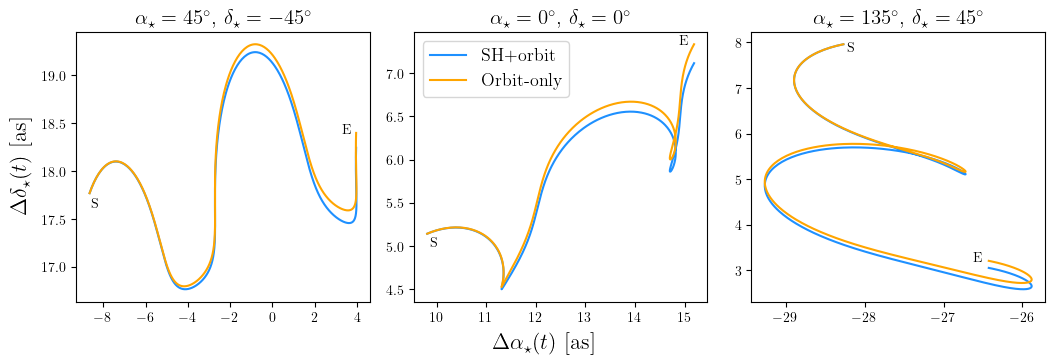

In [8]:
# Create a three-panel figure showing apparent stellar trails for different sky positions
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.5), gridspec_kw={"wspace": 0.15})

# Select representative stellar positions in ICRF coordinates (alpha, delta)
star_positions = [
    (np.pi/4, -np.pi/4),
    (0, 0),
    (3*np.pi/4, np.pi/4)
]

# Generate stellar aberration trails for each selected sky position
for i, (alpha_star_0, delta_star_0) in enumerate(star_positions):

    ax = axes[i]

    # Convert initial stellar coordinates from radians to degrees for plotting
    alpha_0_deg = np.degrees(alpha_star_0)
    delta_0_deg = np.degrees(delta_star_0)

    # Compute trails including both the TESS orbit and a DM subhalo-induced velocity perturbation
    alpha_star_deg, delta_star_deg = star_trail(
        alpha_star_0,
        delta_star_0,
        v_TESS(bool_SH=True, bool_orbit=True)
    )

    # Compute standard orbital aberration without a DM perturbation
    alpha_star_deg_orbit, delta_star_deg_orbit = star_trail(
        alpha_star_0,
        delta_star_0,
        v_TESS(bool_SH=False, bool_orbit=True)
    )

    # Select representative time points along the trajectory
    indices = np.linspace(0, len(alpha_star_deg) - 1, 6, dtype=int)

    # Plot combined DM subhalo + orbital aberration trail
    plot_trail(
        alpha_star_deg,
        delta_star_deg,
        alpha_0_deg,
        delta_0_deg,
        color="dodgerblue",
        label="SH+orbit" if i == 1 else None,
        indices=indices,
        ax=ax
    )

    # Plot orbital aberration reference trail
    x_orbit, y_orbit = plot_trail(
        alpha_star_deg_orbit,
        delta_star_deg_orbit,
        alpha_0_deg,
        delta_0_deg,
        color="orange",
        label="Orbit-only" if i == 1 else None,
        indices=indices,
        ax=ax
    )

    # Label the initial stellar position
    ax.set_title(
        rf"$\alpha_\star={alpha_0_deg:.0f}^\circ$, $\delta_\star={delta_0_deg:.0f}^\circ$",
        fontsize=15
    )

    # Mark start and end points of the trajectory
    ax.text(
        x_orbit[0] + 0.05,
        y_orbit[0] - 0.15,
        "S",
        color="black",
        fontweight='bold',
        fontsize=10
    )

    ax.text(
        x_orbit[-1] - (0.65 if i == 0 else 0.3 if i == 1 else 0.2),
        y_orbit[-1],
        "E",
        color="black",
        fontweight='bold',
        fontsize=10
    )

# Add legend only to the central panel
axes[1].legend(loc="upper left", fontsize=13)

# Add shared axis labels
fig.supxlabel(r"$\Delta \alpha_\star(t)$ [as]", fontsize=16, y=-0.04)
fig.supylabel(r"$\Delta \delta_\star(t)$ [as]", fontsize=16, x=0.072)

plt.show()